In [2]:
#%pip install torchvision

In [1]:
import torch
import os
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image

In [2]:
# Images load=> transform =>dataset of all imgs
class ImageProcessor:
    def __init__(self, root_dir_path, transformations=None):
        self.root_dir_path=root_dir_path
        self.transformations=transformations

        #List of paths for all images
        self.all_img_paths= [os.path.join(root_dir_path, img)
                             for img in os.listdir(root_dir_path)]

    def __len__(self):
        return len(self.all_img_paths)

    def __getitem__(self, idx):
        img_path=self.all_img_paths[idx]
        img=Image.open(img_path).convert("RGB")

        if self.transformations:
            img=self.transformations(img)

        return img

In [3]:
root_dir_path="./img_align_celeba"
transformations=transforms.Compose([
    transforms.CenterCrop(178),  #178x218=>178x178
    transforms.Resize(64),  #64x64
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))  #[-1,1]
])

In [4]:
dataset=ImageProcessor(root_dir_path, transformations)
print(f"loaded {len(dataset)} images")

loaded 202599 images


In [5]:
dataloader=DataLoader(dataset, batch_size=128, shuffle=True)

## Generator Network

In [6]:
import torch.nn as nn
import torch.optim as optim
import numpy as np

In [7]:
class Generator(nn.Module):
    def __init__(self, z_dim=100, img_channels=3): #3 is for RGB
        super(Generator, self). __init__()

        #Fully Connected(Dense) Layer
        self.model=nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.ReLU(),

            nn.Linear(512, 1024),
            nn.ReLU(),

            nn.Linear(1024, 64*64*img_channels),
            nn.Tanh() # ByDefault [-1,1]
        )
        
    def forward(self, z):
        img= self.model(z)
        img= img.view(img.size(0),3,64,64)
        return img


## Discriminator Network

In [8]:
class Discriminator(nn.Module):
    def __init__(self, img_channels=3): #3 is for RGB
        super(Discriminator, self). __init__()

        #Fully Connected(Dense) Layer
        self.model=nn.Sequential(
            nn.Flatten(), #4DTensor => 1D
            
            nn.Linear(img_channels*64*64, 1024),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(1024,512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(256, 1),
            nn.Sigmoid() # Probability of being real/fake
        )
        
    def forward(self, img):
        return self.model(img)
        


In [9]:
GAN_loss=nn.BCELoss()

generator=Generator()
g_optimizer=optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5,0.999))

discriminator=Discriminator()
d_optimizer=optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5,0.999))

In [10]:
import torch
if torch.backends.mps.is_available():
    device=torch.device("mps")
elif torch.cuda.is_available():
    device=torch.device("cuda")
else:
    device=torch.device("cpu")

print(f"Device:{device}")
    

Device:cuda


In [11]:
generator=generator.to(device)
discriminator=discriminator.to(device)

### Training the GAN

In [12]:
def train(generator, discriminator, dataloader, epochs=10):
    for epoch in range(epochs):
        for i, imgs in enumerate(dataloader):
            real_imgs=imgs.to(device)
            batch_size=real_imgs.size(0)
            #Create real image labels and fake image labels
            real_labels=torch.ones(batch_size,1).to(device) #[1,1,1,1,....]
            fake_labels=torch.zeros(batch_size,1).to(device) #[0,0,0,0,.....]

            # Train the Discriminator
            d_optimizer.zero_grad()
            fake_data = generator(torch.randn(batch_size, 100, device=device))

            real_loss=GAN_loss(discriminator(real_imgs), real_labels)
            fake_loss=GAN_loss(discriminator(fake_data.detach()), fake_labels)

            d_loss=(real_loss+fake_loss)/2

            d_loss.backward()
            d_optimizer.step()



            # Train the Generator
            g_optimizer.zero_grad()
            g_loss=GAN_loss(discriminator(fake_data), real_labels)
            g_loss.backward()
            g_optimizer.step()

            if i%50==0:
                print(f"for epoch:{epoch+1}/{epochs}  batch:{i+1}  G-Loss:{g_loss}  D-Loss:{d_loss} ")


        # Save Generated images for each epoch
        save_generated_images(generator, epoch, device)

In [13]:
import matplotlib.pyplot as plt
import torchvision

def save_generated_images(generator, epoch, device, num_imgs=8):
    z=torch.randn(num_imgs,100, device=device)
    generated_imgs=generator(z).detach().cpu()

    grid=torchvision.utils.make_grid(generated_imgs,nrow=4, normalize=True)
    plt.imshow(np.transpose(grid,(1,2,0)))
    plt.title(f"epoch {epoch+1}")
    plt.axis("off")
    plt.show()






    

for epoch:1/5  batch:1  G-Loss:0.7001115083694458  D-Loss:0.6903300285339355 
for epoch:1/5  batch:51  G-Loss:1.0134296417236328  D-Loss:0.26905176043510437 
for epoch:1/5  batch:101  G-Loss:1.9734649658203125  D-Loss:0.17778056859970093 
for epoch:1/5  batch:151  G-Loss:1.5430517196655273  D-Loss:0.31422731280326843 
for epoch:1/5  batch:201  G-Loss:1.445876121520996  D-Loss:0.22140833735466003 
for epoch:1/5  batch:251  G-Loss:2.515127658843994  D-Loss:0.22568829357624054 
for epoch:1/5  batch:301  G-Loss:2.431246280670166  D-Loss:0.08859333395957947 
for epoch:1/5  batch:351  G-Loss:1.3933196067810059  D-Loss:0.31053364276885986 
for epoch:1/5  batch:401  G-Loss:0.5763475894927979  D-Loss:0.639238178730011 
for epoch:1/5  batch:451  G-Loss:2.6188180446624756  D-Loss:0.15869250893592834 
for epoch:1/5  batch:501  G-Loss:2.5934321880340576  D-Loss:0.08856912702322006 
for epoch:1/5  batch:551  G-Loss:1.810459017753601  D-Loss:0.19584213197231293 
for epoch:1/5  batch:601  G-Loss:2.180

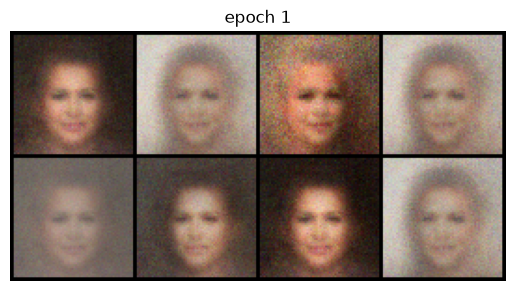

for epoch:2/5  batch:1  G-Loss:2.3215065002441406  D-Loss:0.27660027146339417 
for epoch:2/5  batch:51  G-Loss:2.9761900901794434  D-Loss:0.33872607350349426 
for epoch:2/5  batch:101  G-Loss:2.2334420680999756  D-Loss:0.14498892426490784 
for epoch:2/5  batch:151  G-Loss:2.601515531539917  D-Loss:0.2548823356628418 
for epoch:2/5  batch:201  G-Loss:3.554993152618408  D-Loss:0.4388640522956848 
for epoch:2/5  batch:251  G-Loss:2.8607616424560547  D-Loss:0.21210573613643646 
for epoch:2/5  batch:301  G-Loss:4.8108110427856445  D-Loss:0.15823376178741455 
for epoch:2/5  batch:351  G-Loss:3.42891263961792  D-Loss:0.2569041848182678 
for epoch:2/5  batch:401  G-Loss:3.1222105026245117  D-Loss:0.19174955785274506 
for epoch:2/5  batch:451  G-Loss:3.6890487670898438  D-Loss:0.18365564942359924 
for epoch:2/5  batch:501  G-Loss:3.002079486846924  D-Loss:0.2459685206413269 
for epoch:2/5  batch:551  G-Loss:3.366326332092285  D-Loss:0.21925784647464752 
for epoch:2/5  batch:601  G-Loss:3.271758

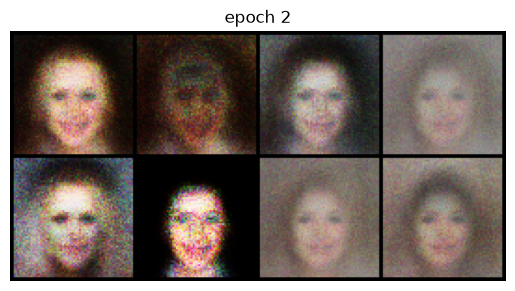

for epoch:3/5  batch:1  G-Loss:2.1858441829681396  D-Loss:0.2836114168167114 
for epoch:3/5  batch:51  G-Loss:2.697010040283203  D-Loss:0.3407469391822815 
for epoch:3/5  batch:101  G-Loss:3.2150492668151855  D-Loss:0.40275824069976807 
for epoch:3/5  batch:151  G-Loss:2.126819133758545  D-Loss:0.2620987296104431 
for epoch:3/5  batch:201  G-Loss:3.7139430046081543  D-Loss:0.30433136224746704 
for epoch:3/5  batch:251  G-Loss:2.447103977203369  D-Loss:0.26949551701545715 
for epoch:3/5  batch:301  G-Loss:2.155252695083618  D-Loss:0.4389418363571167 
for epoch:3/5  batch:351  G-Loss:3.285895347595215  D-Loss:0.3325340151786804 
for epoch:3/5  batch:401  G-Loss:2.485588550567627  D-Loss:0.3491142988204956 
for epoch:3/5  batch:451  G-Loss:2.8011298179626465  D-Loss:0.2902959883213043 
for epoch:3/5  batch:501  G-Loss:3.0134520530700684  D-Loss:0.26343846321105957 
for epoch:3/5  batch:551  G-Loss:3.859138011932373  D-Loss:0.34541961550712585 
for epoch:3/5  batch:601  G-Loss:2.8051028251

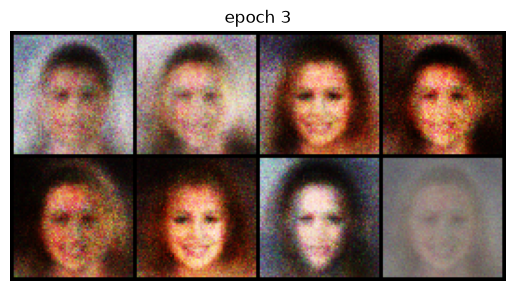

for epoch:4/5  batch:1  G-Loss:2.354037284851074  D-Loss:0.3593430519104004 
for epoch:4/5  batch:51  G-Loss:2.7120213508605957  D-Loss:0.5592823624610901 
for epoch:4/5  batch:101  G-Loss:2.282059669494629  D-Loss:0.3651098608970642 
for epoch:4/5  batch:151  G-Loss:2.1147091388702393  D-Loss:0.32689398527145386 
for epoch:4/5  batch:201  G-Loss:2.032714366912842  D-Loss:0.4412253201007843 
for epoch:4/5  batch:251  G-Loss:2.929337501525879  D-Loss:0.3550395667552948 
for epoch:4/5  batch:301  G-Loss:1.817290186882019  D-Loss:0.36001619696617126 
for epoch:4/5  batch:351  G-Loss:1.8672409057617188  D-Loss:0.4760485291481018 
for epoch:4/5  batch:401  G-Loss:2.3304009437561035  D-Loss:0.3756769895553589 
for epoch:4/5  batch:451  G-Loss:2.136810541152954  D-Loss:0.3504562973976135 
for epoch:4/5  batch:501  G-Loss:1.6709576845169067  D-Loss:0.4879823625087738 
for epoch:4/5  batch:551  G-Loss:1.60072660446167  D-Loss:0.5137183666229248 
for epoch:4/5  batch:601  G-Loss:1.91054201126098

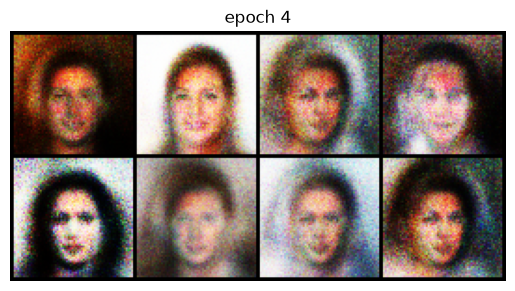

for epoch:5/5  batch:1  G-Loss:2.1019625663757324  D-Loss:0.5002082586288452 
for epoch:5/5  batch:51  G-Loss:1.6156013011932373  D-Loss:0.3726356625556946 
for epoch:5/5  batch:101  G-Loss:1.7148082256317139  D-Loss:0.45036056637763977 
for epoch:5/5  batch:151  G-Loss:1.949678659439087  D-Loss:0.4374503493309021 
for epoch:5/5  batch:201  G-Loss:2.702561378479004  D-Loss:0.45214739441871643 
for epoch:5/5  batch:251  G-Loss:1.973576545715332  D-Loss:0.4196210503578186 
for epoch:5/5  batch:301  G-Loss:1.7989810705184937  D-Loss:0.5176711082458496 
for epoch:5/5  batch:351  G-Loss:2.1940219402313232  D-Loss:0.4542951285839081 
for epoch:5/5  batch:401  G-Loss:1.8535419702529907  D-Loss:0.43438103795051575 
for epoch:5/5  batch:451  G-Loss:1.6954026222229004  D-Loss:0.4165671467781067 
for epoch:5/5  batch:501  G-Loss:1.8943662643432617  D-Loss:0.467343807220459 
for epoch:5/5  batch:551  G-Loss:2.1565611362457275  D-Loss:0.5080371499061584 
for epoch:5/5  batch:601  G-Loss:1.477525711

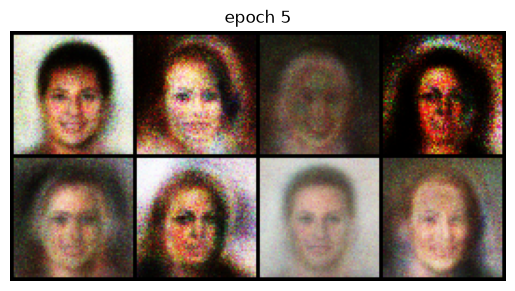

In [14]:
train(generator, discriminator, dataloader, epochs=5)